In [267]:
import numpy as np, torch

# Neuromancer imports: modeling, loss, logging, system dynamics
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.sindy.fx_library import fx_policy_library
from results.utils import *

# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [268]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


In [269]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*u_0 + -0.001*u_1 + 0.040*u_0*u_1 + -0.004*x0*u_0 + 0.013*x1*u_0 + -0.015*x0*u_1 + -0.010*x1*u_1 + -0.048*sqrt(x0) + -0.033*sqrt(x1)

dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*u_0 + -0.001*u_1 + 0.040*u_0*u_1 + -0.004*x0*u_0 + 0.013*x1*u_0 + -0.015*x0*u_1 + -0.010*x1*u_1 + -0.048*sqrt(x0) + -0.033*sqrt(x1)



In [270]:
import os, glob, torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here

for i, model in enumerate(fx_models):
    pattern = os.path.join(models_dir, f"trained_dynamics_x{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for x{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded x{i} from {os.path.basename(ckpt)}")


Loaded x0 from trained_dynamics_x0_20250809_160941.pth
Loaded x1 from trained_dynamics_x1_20250809_160941.pth


In [271]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations

run_id = 3
### SPARSE DICTIONARY (SD) MODELS ###
SD_SINDy_policies = [fx_policy_library(nx=nx, nref=1,
                              policy_name=f"u_{k}",
                              seed=1, device=device)
                              for k in range(nu)]


models_dir = f"results/tests/sparse/run_{run_id}/SINDy/saved_models"
for i, model in enumerate(SD_SINDy_policies):
    pattern = os.path.join(models_dir, f"trained_policy_{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for u{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded SD-SINDy policy:  u{i} from {os.path.basename(ckpt)}")


import torch.nn as nn

def prune_model(model, tol: float = 0.0, *, in_place: bool = False, reinit: bool = False, reinit_std: float = 0.01):
    """
    Prune terms whose |coef| <= tol and remove the corresponding entries from the library.
    Mirrors the 'mask -> active_idx -> slice library + coef' approach in your reference.

    Args:
        model: object with
            - .coef: (n_terms,) or (n_terms, out_dim) tensor / nn.Parameter
            - .library.function_names or .library.functions_names: list[str]
            - optional .library.library: list[callable/objs]
            - optional .library.functions: list[callable]
            - optional .library.shape: tuple
            - optional .library.term_indices: list[...]  (pruned if present)
        tol: threshold; keep a row if any |coef[row]| > tol (for 2D).
        in_place: modify the passed model in place; otherwise returns a deep-copied pruned model.
        reinit: if True, reinitialize the kept coefficients with N(0, reinit_std^2).
        reinit_std: std for reinitialization when reinit=True.

    Returns:
        pruned model (same object if in_place=True, otherwise a deep-copied one).
    """
    m = model if in_place else copy.deepcopy(model)

    with torch.no_grad():
        coef = m.coef
        if coef.ndim == 1:
            mask = torch.abs(coef) > tol                   # (n_terms,)
        elif coef.ndim == 2:
            mask = torch.abs(coef).amax(dim=1) > tol       # (n_terms,)
        else:
            raise ValueError(f"Unsupported coef ndim={coef.ndim}")

        active_idx = torch.nonzero(mask, as_tuple=False).view(-1)
        if active_idx.numel() == 0:
            # keep at least one term to avoid degenerate model
            print("Warning: all terms would be pruned; keeping the largest-magnitude term.")
            if coef.ndim == 1:
                keep_idx = torch.argmax(torch.abs(coef)).view(-1)
            else:
                keep_idx = torch.argmax(torch.abs(coef).amax(dim=1)).view(-1)
            active_idx = keep_idx

        idx = active_idx.tolist()

        # --- slice coefficients
        if reinit:
            new_coef = torch.randn_like(coef[idx, ...]) * reinit_std if coef.ndim == 2 \
                       else torch.randn_like(coef[idx]) * reinit_std
        else:
            new_coef = coef[idx, ...] if coef.ndim == 2 else coef[idx]

        # preserve Parameter-ness and requires_grad
        if isinstance(m.coef, nn.Parameter):
            m.coef = nn.Parameter(new_coef, requires_grad=model.coef.requires_grad)
        else:
            m.coef = new_coef

        # --- resolve names attribute
        names_attr = 'function_names' if hasattr(m.library, 'function_names') else (
                     'functions_names' if hasattr(m.library, 'functions_names') else None)
        if names_attr is not None:
            names = getattr(m.library, names_attr)
            setattr(m.library, names_attr, [names[i] for i in idx])

        # --- prune parallel library structures if present
        if hasattr(m.library, 'library'):
            lib_list = getattr(m.library, 'library')
            setattr(m.library, 'library', [lib_list[i] for i in idx])

        if hasattr(m.library, 'functions'):
            funcs = getattr(m.library, 'functions')
            setattr(m.library, 'functions', [funcs[i] for i in idx])

        if hasattr(m.library, 'term_indices'):
            term_idx = getattr(m.library, 'term_indices')
            setattr(m.library, 'term_indices', [term_idx[i] for i in idx])

        # --- update shape if provided
        if hasattr(m.library, 'shape'):
            old_shape = getattr(m.library, 'shape')
            # assume shape = (n_terms, something)
            setattr(m.library, 'shape', (len(idx), old_shape[1] if len(old_shape) > 1 else 1))

    return m

import torch
import torch.nn as nn

class VectorizedPolicy(nn.Module):
    """
    Vectorized 2-channel policy:
      u0 basis: [cos(2*x0), cos(2*x1), cos(2*r0), sin(2*r0)]   (4 terms)
      u1 basis: [cos(2*x0), cos(2*x1)]                         (2 terms)

    This module has NO parameters of its own. It reads the .coef Parameters
    from the provided SINDy policy modules and backprop flows into them.
    """
    def __init__(self, sindy_policies, umin=None, umax=None):
        super().__init__()
        assert len(sindy_policies) == 2, "Expected exactly 2 policies (u0, u1)."
        self.policies = sindy_policies   # keep references; no registration
        self.umin = umin
        self.umax = umax

    def forward(self, x: torch.Tensor, r: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 2)  -> [x0, x1]
        r: (B, 2)  -> [r0, r1]  (only r0 used here)
        returns: (B, 2)  -> [u0, u1]
        """
        if x.dim() != 2 or x.size(-1) != 2:
            raise ValueError("x must be of shape (B, 2)")
        if r.dim() != 2 or r.size(-1) != 2:
            raise ValueError("r must be of shape (B, 2)")

        x0, x1 = x[:, 0], x[:, 1]
        r0     = r[:, 0]

        # shared trig terms (vectorized)
        c2x0 = torch.cos(2 * x0)
        c2x1 = torch.cos(2 * x1)
        c2r0 = torch.cos(2 * r0)
        s2r0 = torch.sin(2 * r0)

        # Feature blocks
        # u0 features: (B, 4)
        Phi_u0 = torch.stack([c2x0, c2x1, c2r0, s2r0], dim=1)
        # u1 features: (B, 2)
        Phi_u1 = torch.stack([c2x0, c2x1], dim=1)

        # Read live coef tensors from policies
        coef_u0 = self.policies[0].coef      # shape (4,) or (4,1)
        coef_u1 = self.policies[1].coef      # shape (2,) or (2,1)

        # Robust matmul for 1D or 2D coefs
        if coef_u0.dim() == 1:
            u0 = Phi_u0 @ coef_u0
        else:
            u0 = (Phi_u0 @ coef_u0).squeeze(-1)

        if coef_u1.dim() == 1:
            u1 = Phi_u1 @ coef_u1
        else:
            u1 = (Phi_u1 @ coef_u1).squeeze(-1)

        U = torch.stack([u0, u1], dim=1)     # (B, 2)

        return torch.clamp(U, self.umin, self.umax) if (self.umin is not None and self.umax is not None) else U


SD_SINDy_policies = [prune_model(fp) for fp in SD_SINDy_policies]



Loaded SD-SINDy policy:  u0 from trained_policy_0_20250808_150421.pth
Loaded SD-SINDy policy:  u1 from trained_policy_1_20250808_150421.pth


### Online Adaptation


#### Copy the old policy and add noise to the system

In [272]:
copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)

vectorized_SD_SINDy_policies = VectorizedPolicy(copy_SD_SINDy_policies, umin=umin, umax=umax)
SD_SINDy_policy_node = Node(
            lambda xn, r: vectorized_SD_SINDy_policies(xn,r),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

In [273]:
# white-box ODE model with no-plant model mismatch
two_tank_noisy = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
gt_model = psl.nonautonomous.TwoTank()

two_tank_noisy.c1 = nn.Parameter(torch.tensor(gt_model.c1+0.05), requires_grad=False)
two_tank_noisy.c2 = nn.Parameter(torch.tensor(gt_model.c2-0.02), requires_grad=False)
gt_model.c1 += 0.05
gt_model.c2 -= 0.02
# integrate continuous time ODE
gt_integrator_noisy = integrators.Euler(two_tank_noisy, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')
#noise_node = Node(lambda x: x+ 0.005* torch.rand(x.shape), ['xn_raw'], ['xn'], name='model')
import copy
gt_sindy_policy_noisy = copy.deepcopy(System([SD_SINDy_policy_node,
                       gt_integrator_node]))

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

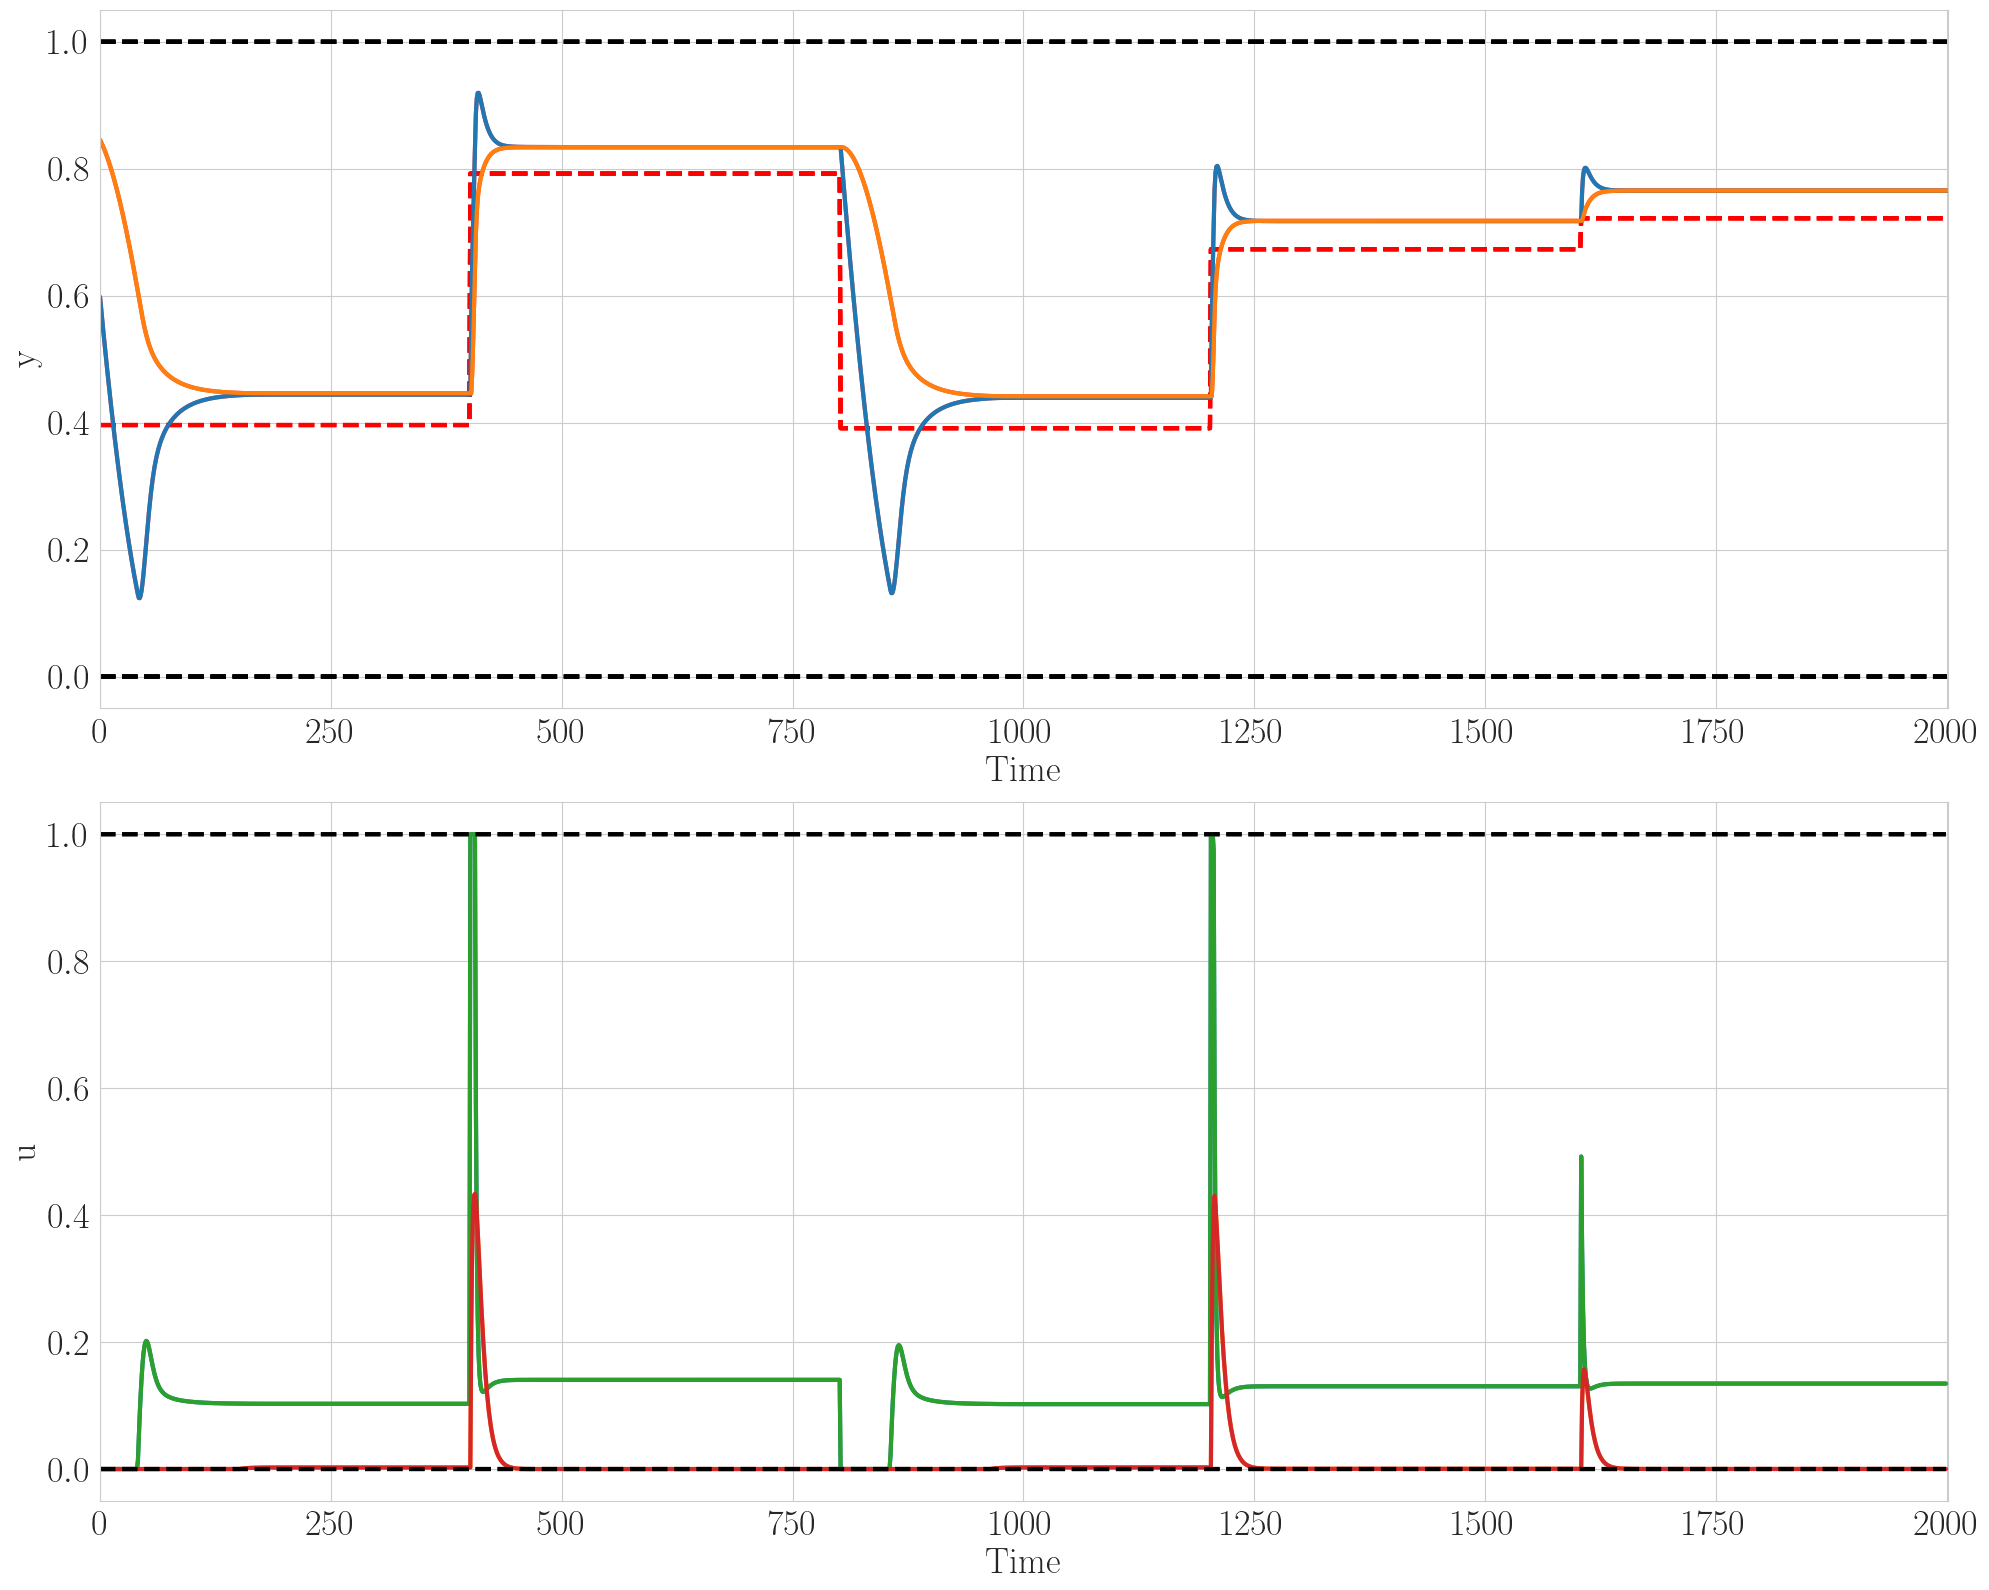

In [274]:
# ---- Setup ----
nsteps = 2000
step_length = 400
N=50
seed = 8
rng = np.random.default_rng(seed)
torch.manual_seed(seed)

# Generate reference signal
np_ref_1 = psl.signals.step(nsteps+2, 1, min=0.2, max=0.8, randsteps=nsteps//step_length, rng=rng)
R_1 = torch.tensor(np_ref_1, dtype=torch.float32).reshape(1, nsteps+2, 1)
torch_ref = torch.cat([R_1, R_1], dim=-1)
xn_test = torch.rand(1, 1, nx, dtype=torch.float32)

# Initial data
data = {
    'xn': xn_test.to(device),
    'x1_n': xn_test[:, :, 0:1].to(device),
    'x2_n': xn_test[:, :, 1:2].to(device),
    'r': torch_ref.to(device)
}


gt_sindy_policy_noisy.nsteps = nsteps
# perform closed-loop simulation
trajectories_before_adaptation = gt_sindy_policy_noisy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories_before_adaptation['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories_before_adaptation['r'].detach().reshape(nsteps + 2, nref),
      U=trajectories_before_adaptation['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

### Training Loop

In [275]:
from SparseDPC.jacobian.vanderpol import build_symbolic_jacobian

#### Create the symbolic jacobian object

In [276]:
jac_sym  = build_symbolic_jacobian(f_dyn_rows=fx_models,
                                   policies=copy_SD_SINDy_policies,
                                   umin=umin, umax=umax, eps=0.0)  # eps=0 to match clamp exactly

In [277]:
for i in range(nx):
    for j in range(len(SD_SINDy_policies[0].coef) + len(SD_SINDy_policies[1].coef)):
        print(f"Derivative for coefficient {j} in f_{i}(x,u) : ",jac_sym.expr[i,j])

Derivative for coefficient 0 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*cos(2*x_0)
Derivative for coefficient 1 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*cos(2*x_1)
Derivative for coefficient 2 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*cos(2*r_0)
Derivative for coefficient 3 in f_0(x,u) :  (0.0766929462552071 - 0.0765727683901787*u_1)*sin(2*r_0)
Derivative for coefficient 4 in f_0(x,u) :  -0.0765727683901787*u_0*cos(2*x_0)
Derivative for coefficient 5 in f_0(x,u) :  -0.0765727683901787*u_0*cos(2*x_1)
Derivative for coefficient 0 in f_1(x,u) :  0.078864298760891*u_1*cos(2*x_0)
Derivative for coefficient 1 in f_1(x,u) :  0.078864298760891*u_1*cos(2*x_1)
Derivative for coefficient 2 in f_1(x,u) :  0.078864298760891*u_1*cos(2*r_0)
Derivative for coefficient 3 in f_1(x,u) :  0.078864298760891*u_1*sin(2*r_0)
Derivative for coefficient 4 in f_1(x,u) :  0.078864298760891*u_0*cos(2*x_0)
Derivative for coefficient 5 in f_1(x,u) :  0.0788642

#### For faster inference, we create a vectorized version of the jacobian from these derivatives.

#### Update on new system

In [281]:
def update_policies(policies, policy_grads, gamma):
    """
    Apply parameter updates to multiple policies.
    """
    with torch.no_grad():
        for p, g in zip(policies, policy_grads):
            p.coef += gamma * g


In [ ]:
# Build lists for dynamics and policies (extend these if you have >2)
x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory = torch.zeros([1, 1, 2])
gamma = 1.0

psi_sizes = [int(n) for n in jac_sym.psi_sizes]  # e.g., [4, 2] — per-policy coef counts

for t in range(1, len(data['r'][0])):
    gt_sindy_policy_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_noisy({
        'xn': x_trajectory[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)
    })

    x = next_step_data['xn'][:, -1, :].detach()
    r = next_step_data['r'][:,  -1, :].detach()
    u = vectorized_SD_SINDy_policies(x, r)

    # error and symbolic Jacobian
    e     = (r - x).reshape(-1, 1)                         # (nx, 1)
    J_sym = jac_sym(x, r, u.detach())                      # (nx, nA) or (1, nx, nA)
    if J_sym.dim() == 3:
        J_sym = J_sym.squeeze(0)                           # ensure (nx, nA)

    # normalized gradient
    Jt_e  = J_sym.T @ e                                    # (nA, 1)
    fro2  = (J_sym * J_sym).sum()                          # scalar
    denom = 1.0 + fro2
    grads_flat = (Jt_e / denom).reshape(-1)                # (nA,)

    # --- split grads per policy and reshape like p.coef ---
    per_policy_grads = []
    offset = 0
    for p, n_k in zip(copy_SD_SINDy_policies, psi_sizes):
        g_slice = grads_flat[offset:offset + n_k].view_as(p.coef)
        per_policy_grads.append(g_slice)
        offset += n_k
    assert offset == grads_flat.numel(), "grads length != sum(psi_sizes)"


    # apply updates
    update_policies(copy_SD_SINDy_policies, per_policy_grads, gamma)

    # log trajectories
    x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,  -1:, :]], dim=1)

results = {"xn": x_trajectory, "u": u_trajectory}


In [ ]:
# Get best results using adaptive horizon MPC

from results.utils import mpc_solve_adaptive_horizon
N=50
MPC_trajectories = mpc_solve_adaptive_horizon(data, gt_model, N_max=N, N_min=2, nsim=nsteps, step_length=step_length, Ru=0.0, Rdu=0.01)

In [286]:
Y_list = [
    trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
    x_trajectory[:,:-1,:].detach().cpu().reshape(nsteps + 1, nx),
    MPC_trajectories['xn'].reshape(nsteps + 1, nx)
]

U_list = [
    trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
    u_trajectory[:,:-2,:].reshape(nsteps, nu),
    MPC_trajectories['u'].reshape(nsteps, nu)
]

R = trajectories_before_adaptation['r'].detach().cpu()[:,:nsteps+1].reshape(nsteps + 1, nref)

# Constraints
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Ymin = xmin * np.ones([nsteps + 1, nx])
Ymax = xmax * np.ones([nsteps + 1, nx])




In [287]:

import re

def convert_to_latex_policy(names):
    """
    Correctly shifts:
    - x_0 -> x_1
    - x_1 -> x_2
    - r_0 -> r
    and applies LaTeX formatting for all terms,
    including inside composite expressions.
    """
    latex_names = []

    for name in names:
        # Step 1: Safely handle r_0 first
        name = re.sub(r'r_0', r'r', name)

        # Step 2: Temporary tags to avoid double-replacement
        name = name.replace('x_0', 'xTEMP0')
        name = name.replace('x_1', 'xTEMP1')

        # Step 3: Now shift safely
        name = name.replace('xTEMP0', 'x_1')
        name = name.replace('xTEMP1', 'x_2')

        # Step 4: LaTeX formatting
        name = name.replace('*', r' \cdot ')  # Multiplications
        name = re.sub(r'sin\((.*?)\)', r'\\sin(\1)', name)
        name = re.sub(r'cos\((.*?)\)', r'\\cos(\1)', name)
        name = re.sub(r'\^(\d+)', r'^{\1}', name)

        # Step 5: Add LaTeX subscripts for any x_N (after shift)
        name = re.sub(r'(?<![a-zA-Z])x_(\d+)', r'x_{\1}', name)

        latex_names.append(rf"${name}$")

    return latex_names

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter

# expects a function `convert_to_latex_policy(names)` in scope

def combined_controller_and_two_policy_heatmaps(
    Y_list, U_list,
    controller_labels,
    fx_policy_SINDy, fx_policy_WB,
    fx_policy_labels,
    R=None,
    style_map=None,
    TS_FIG_WIDTH=4, TS_FIG_HEIGHT=2,
    CELL_SIZE=0.3,
    FONT_SIZE_COEFS=5,
    FONT_SIZE_COEFS_LABELS=8,
    save_name="CombinedPlot.pdf",
    title=None,
    xmin=None, xmax=None,
    umin=None, umax=None,
    ACTIVE_TOL=1e-8, VMIN=-4, VMAX=4
):
    # ---------- helpers ----------
    def _names_attr(lib):
        if hasattr(lib, 'function_names'): return 'function_names'
        if hasattr(lib, 'functions_names'): return 'functions_names'
        raise AttributeError("Library needs function_names/functions_names")
    def _get_names(m): return getattr(m.library, _names_attr(m.library))
    def _coef1xN(t):
        a = t.detach().cpu().numpy()
        if a.ndim == 2: a = a[:, 0]
        return a.reshape(1, -1)
    def _ordered_union(pols):
        seen, out = set(), []
        for p in pols:
            for n in _get_names(p):
                if n not in seen: seen.add(n); out.append(n)
        return out
    def _aligned_row(p, union):
        names = _get_names(p); idx = {n:i for i,n in enumerate(names)}
        row = np.zeros((1, len(union)))
        c = _coef1xN(p.coef)
        for j,n in enumerate(union):
            i = idx.get(n)
            if i is not None: row[0, j] = c[0, i]
        return row

    # --- helpers: bold borders ---
    def _bold_spines(ax, lw=0.5, color="black"):
        for side in ("left","right","top","bottom"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(lw)
            ax.spines[side].set_edgecolor(color)

    def _latex_text(s: str) -> str:
        """Wrap plain text in LaTeX math mode with \\text{...}, preserving spaces."""
        if "$" in s:       # already LaTeX, don't double-wrap
            return s
        # escape LaTeX specials
        for k, v in {
            "\\": r"\textbackslash{}",
            "{": r"\{", "}": r"\}",
            "#": r"\#", "$": r"\$", "%": r"\%",
            "&": r"\&", "_": r"\_", "^": r"\^{}", "~": r"\~{}",
        }.items():
            s = s.replace(k, v)
        return rf"$\text{{{s}}}$"
        # put this near the top (you already set usetex=True)
    sns.set_style("whitegrid")
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "text.latex.preamble": r"\usepackage{amsmath}",   # needed for \text
    })

    # ---------- align + active mask (shared x-ticks) ----------
    union = _ordered_union(list(fx_policy_SINDy) + list(fx_policy_WB))
    coef_S_full = np.vstack([_aligned_row(fx, union) for fx in fx_policy_SINDy])
    coef_W_full = np.vstack([_aligned_row(fx, union) for fx in fx_policy_WB])

    active = (np.abs(coef_S_full).max(0) > ACTIVE_TOL) | (np.abs(coef_W_full).max(0) > ACTIVE_TOL)
    if not active.any():
        active[np.argmax(np.abs(np.r_[coef_S_full, coef_W_full]).max(0))] = True

    coef_S, coef_W = coef_S_full[:, active], coef_W_full[:, active]
    function_names_latex = [n for n,k in zip(convert_to_latex_policy(union), active) if k]
    n_terms = len(function_names_latex)

    # ---------- sizing ----------
    heatmap_width = n_terms * CELL_SIZE
    heatmap_height = 0.8
    gap_between_heatmaps = 0.01
    gap_between_blocks   = 0.01

    fig_height = TS_FIG_HEIGHT + 2*heatmap_height + gap_between_heatmaps + gap_between_blocks
    fig = plt.figure(figsize=(TS_FIG_WIDTH, fig_height))

    # ---------- time series (unchanged layout) ----------
    nsteps = Y_list[0].shape[0] - 1
    time = np.arange(nsteps + 1)

    top_margin = 0.62
    plot_height = 0.2
    plot_width = 0.8
    left_margin = (1 - plot_width) / 2
    heatmap_width_figunits = heatmap_width / TS_FIG_WIDTH

    plot_width = 0.38
    ax1 = fig.add_axes([left_margin, top_margin, plot_width, plot_height])
    gap_between_ts_plots = 0.07
    ax2 = fig.add_axes([left_margin + plot_width + gap_between_ts_plots, top_margin, plot_width, plot_height])

    legend_ax = fig.add_axes([left_margin, top_margin + plot_height + 0.001, 2*plot_width + 0.04, 0.05])
    legend_ax.axis("off")

    legend_handles = []
    if R is not None:
        h_ref, = ax1.plot(time, R[:, 0], '--', linewidth=0.7, color='red', label=r"$\mathrm{Ref}$")
        legend_handles.append(h_ref)

    for i in range(len(Y_list)):
        label = controller_labels[i]
        cfg = style_map[label]

        # Accept dict or tuple:
        if isinstance(cfg, dict):
            linestyle = cfg.get("linestyle", "-")
            linewidth = cfg.get("linewidth", 1.5)
            alpha     = cfg.get("alpha", 1.0)
            color     = cfg.get("color", plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10])
        else:
            # tuple formats: (linestyle, linewidth, alpha, color?) or (linestyle, linewidth, alpha)
            if len(cfg) >= 4:
                linestyle, linewidth, alpha, color = cfg[:4]
            else:
                linestyle, linewidth, alpha = cfg[:3]
                color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

        # plot with the color from style_map
        ax1.plot(time, Y_list[i][:, 0], linestyle=linestyle, linewidth=linewidth, alpha=alpha, color=color)
        ax1.plot(time, Y_list[i][:, 1], linestyle="--", linewidth=linewidth, alpha=alpha, color=color)
        ax2.plot(time[:-1], U_list[i][:, 0], linestyle=linestyle, linewidth=linewidth, alpha=alpha, color=color)
        ax2.plot(time[:-1], U_list[i][:, 1], linestyle="--", linewidth=linewidth, alpha=alpha, color=color)

        legend_handles.append(Line2D(
            [0], [0],
            color=color, linewidth=1.3, linestyle=linestyle,
            label=_latex_text(label)
        ))

    legend_ax.legend(
        legend_handles, [h.get_label() for h in legend_handles],
        loc='center', ncol=len(legend_handles), fontsize=12,
        frameon=False, handlelength=2.5, columnspacing=1.5
    )


    if xmin is not None: ax1.hlines(xmin, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    if xmax is not None: ax1.hlines(xmax, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    if umin is not None: ax2.hlines(umin, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    if umax is not None: ax2.hlines(umax, 0, nsteps, colors='black', linewidth=0.4, linestyle='--')
    ax1.set_ylabel(r"$x$", fontsize=15, rotation=0, labelpad=16); ax1.set_xlabel(r"$t$", fontsize=15, labelpad=8)
    ax2.set_ylabel(r"$u$", fontsize=15, rotation=0, labelpad=16); ax2.set_xlabel(r"$t$", fontsize=15, labelpad=8)
    ax1.set_xlim([0, nsteps]); ax2.set_xlim([0, nsteps])
    ax1.tick_params(axis='both', labelsize=10); ax2.tick_params(axis='both', labelsize=10)
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    _bold_spines(ax1, lw=0.8)
    _bold_spines(ax2, lw=0.8)

    # ---------- heatmaps directly under TS (side-by-side, aligned to TS) ----------
    hm_w = heatmap_width / TS_FIG_WIDTH
    hm_h = heatmap_height / fig_height

    V_GAP = 0.05        # vertical gap under TS row (figure units)
    BOTTOM_SHIFT = 0.02 # extra downward shift (figure units)
    SHRINK_GAP_FRAC = 0.1  # 0..1 pull the two heatmaps toward each other

    bbox1 = ax1.get_position()
    bbox2 = ax2.get_position()
    c1 = bbox1.x0 + bbox1.width / 2.0
    c2 = bbox2.x0 + bbox2.width / 2.0
    hm_bottom = min(bbox1.y0, bbox2.y0) - V_GAP - hm_h - BOTTOM_SHIFT
    gap_current = (c2 - c1) - hm_w
    pull = max(0.0, SHRINK_GAP_FRAC * gap_current / 2.0)

    ax3_left = c1 - hm_w/2.0 + pull
    ax4_left = c2 - hm_w/2.0 - pull
    ax3 = fig.add_axes([ax3_left, hm_bottom, hm_w, hm_h])  # left heatmap (SINDy)
    ax4 = fig.add_axes([ax4_left, hm_bottom, hm_w, hm_h])  # right heatmap (WB)

    # ---------- heatmaps (rectangular cells + LaTeX annotations) ----------
    DECIMALS = 3
    CELL_ASPECT = 0.6
    CELL_BORDER = 0.5
    LABEL_PAD = 30

    sns_plots = []
    for coef, ax, label in [(coef_S, ax3, r"$\mathrm{Before}$"),
                            (coef_W, ax4, r"$\mathrm{After}$")]:
        annot_str = np.array([[rf"${v:.{DECIMALS}f}$" for v in row] for row in coef])
        hm = sns.heatmap(
            coef,
            annot=annot_str, fmt="",
            cmap="RdBu_r", center=0, vmin=VMIN, vmax=VMAX,
            square=False, linewidths=CELL_BORDER, linecolor='black',
            xticklabels=function_names_latex, yticklabels=fx_policy_labels,
            cbar=False, annot_kws={"size": FONT_SIZE_COEFS}, ax=ax
        )
        sns_plots.append(hm)
        ax.set_aspect(CELL_ASPECT)
        ax.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE_COEFS_LABELS, pad=1)
        ax.tick_params(axis='y', rotation=0,  labelsize=FONT_SIZE_COEFS_LABELS, pad=5)
        ax.add_patch(patches.Rectangle((0,0), coef.shape[1], coef.shape[0],
                                       fill=False, ec='black', lw=0.75, zorder=10, clip_on=False))
        ax.annotate(label, xy=(0, 0.5), xycoords='axes fraction',
                    xytext=(-LABEL_PAD, 0), textcoords='offset points',
                    ha='right', va='center', fontsize=12, annotation_clip=False)

    # shared colorbar (to the right of the right heatmap) with LaTeX ticks
    posR = ax4.get_position()
    cbar_ax = fig.add_axes([posR.x1 + 0.01, posR.y0, 0.015, posR.height])
    cbar = plt.colorbar(sns_plots[0].collections[0], cax=cbar_ax)
    cbar.ax.tick_params(labelsize=6)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: rf"${v:.{DECIMALS}f}$"))
    cbar.update_ticks()

    if title: fig.suptitle(title, fontsize=14, fontweight='bold', y=0.99)
    if save_name:
        file_format = save_name.split('.')[-1]
        fig.savefig(save_name, format=file_format, bbox_inches="tight")
    plt.show()

In [288]:
controller_labels = ["Before Adaptation", "Online Adaptation", "MPC"]
style_map = {
    "Before Adaptation": ("-", 1.1, 0.5, "darkorange"),
    "Online Adaptation": ("-", 1.1, 0.8, "royalblue"),
    "MPC": ("-", 1.1, 0.5, "darkgreen")
}

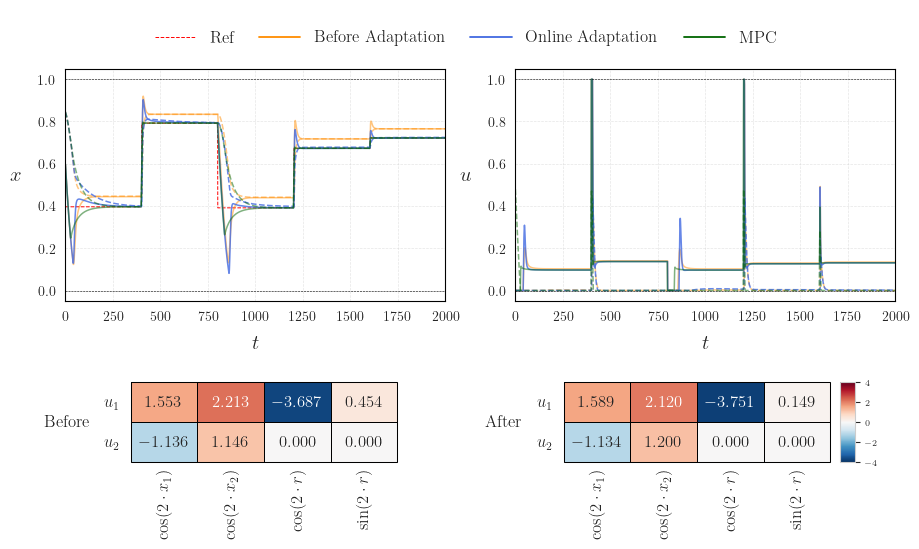

In [289]:
combined_controller_and_two_policy_heatmaps(
    Y_list=Y_list,
    U_list=U_list,
    controller_labels=controller_labels,
    fx_policy_SINDy=SD_SINDy_policies,
    fx_policy_WB=copy_SD_SINDy_policies,
    fx_policy_labels=[r"${u}_1$", r"${u}_2$"],
    R=R,
    style_map=style_map,
    TS_FIG_WIDTH=10,
    TS_FIG_HEIGHT=10,
    CELL_SIZE=0.7,
    FONT_SIZE_COEFS=12,
    FONT_SIZE_COEFS_LABELS=12,
    xmin=0.0, xmax=1.0,
    umin=0.0, umax=1.0,
    title=None,
    save_name="results/TwoTank_Adaptation_Jacobian.pdf"
)

In [292]:
import time, os, gc
import psutil
import torch
import numpy as np
# assumes: copy, Node, System, psl, Jmodule, jac_sym (for psi_sizes), etc. already defined

process = psutil.Process(os.getpid())

def gpu_reset():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

def gpu_read():
    if not torch.cuda.is_available():
        return 0.0, 0.0
    torch.cuda.synchronize()
    cur = torch.cuda.memory_allocated() / 1024**2  # MB
    peak = torch.cuda.max_memory_allocated() / 1024**2
    return cur, peak

times = []
gpu_peaks = []
cpu_deltas = []

for seed in range(20):
    # --- reset meters
    gpu_reset()
    cpu_before = process.memory_info().rss / 1024**2  # MB

    init_time = time.time()

    # ====== YOUR ORIGINAL CODE (unchanged logic) =======================
    copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)

    vectorized_SD_SINDy_policies = VectorizedPolicy(copy_SD_SINDy_policies, umin=umin, umax=umax)
    SD_SINDy_policy_node = Node(
                lambda xn, r: vectorized_SD_SINDy_policies(xn,r),
                ['xn', 'r'], ['u'],
                name="policy_combined"
            )
    gt_sindy_policy_noisy = copy.deepcopy(System([SD_SINDy_policy_node,
                       gt_integrator_node]))

    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    np_refs = psl.signals.step(nsteps+1, 1, min=xmin+0.2, max=xmax-0.2, randsteps=5, rng=rng)
    R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
    torch_ref = torch.cat([R, R], dim=-1)

    data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32),
            'r': torch_ref}

    x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
    u_trajectory = torch.zeros([1, 1, 2])
    gamma = 1.
    error_hist, f_hist = [], []

    for t in range(1, len(data['r'][0])):
        gt_sindy_policy_noisy.nsteps = 1
        next_step_data = gt_sindy_policy_noisy({
            'xn': x_trajectory[:, -1, :].unsqueeze(0),
            'r' : data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)
        })

        x = next_step_data['xn'][:, -1, :].detach()
        r = next_step_data['r'][:,  -1, :].detach()
        u = vectorized_SD_SINDy_policies(x, r)

        # error and symbolic Jacobian
        e     = (r - x).reshape(-1, 1)                         # (nx, 1)
        J_sym = jac_sym(x, r, u.detach())                      # (nx, nA) or (1, nx, nA)
        if J_sym.dim() == 3:
            J_sym = J_sym.squeeze(0)                           # ensure (nx, nA)

        # normalized gradient
        Jt_e  = J_sym.T @ e                                    # (nA, 1)
        fro2  = (J_sym * J_sym).sum()                          # scalar
        denom = 1.0 + fro2
        grads_flat = (Jt_e / denom).reshape(-1)                # (nA,)

        # --- split grads per policy and reshape like p.coef ---
        per_policy_grads = []
        offset = 0
        for p, n_k in zip(copy_SD_SINDy_policies, psi_sizes):
            g_slice = grads_flat[offset:offset + n_k].view_as(p.coef)
            per_policy_grads.append(g_slice)
            offset += n_k
        assert offset == grads_flat.numel(), "grads length != sum(psi_sizes)"

        # apply updates
        update_policies(copy_SD_SINDy_policies, per_policy_grads, gamma)

        # log trajectories
        x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
        u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,  -1:, :]], dim=1)

        # cleanup per step to limit memory growth
        del next_step_data, J_sym, grads_flat, x, u, r, e
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    # ====== END YOUR CODE ==============================================

    end_time = time.time()
    times.append(end_time - init_time)

    # --- read meters
    cur_gpu, peak_gpu = gpu_read()
    gpu_peaks.append(peak_gpu)

    cpu_after = process.memory_info().rss / 1024**2
    cpu_deltas.append(max(0.0, cpu_after - cpu_before))  # MB increased during this seed

    # Aggressive cleanup between seeds
    del copy_SD_SINDy_policies, gt_sindy_policy_noisy, data, x_trajectory, u_trajectory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Total time: {np.sum(times):.3f}s | Avg: {np.mean(times):.3f}s")
print(f"Peak GPU per seed (MB): mean={np.mean(gpu_peaks):.1f}, max={np.max(gpu_peaks):.1f}")
print(f"CPU ΔRSS per seed (MB): mean={np.mean(cpu_deltas):.1f}, max={np.max(cpu_deltas):.1f}")


Total time: 19.719s | Avg: 0.986s
Peak GPU per seed (MB): mean=0.0, max=0.0
CPU ΔRSS per seed (MB): mean=1.3, max=25.9
